In [2]:
import pandas as pd

df = pd.read_csv("sleepedf_SC_merged_epochs.csv")
df.head()


,recording_id,epoch,epoch_start_sec,epoch_end_sec,sleep_stage,EEG Fpz-Cz_mean,EEG Fpz-Cz_std,EEG Fpz-Cz_rms,EEG Pz-Oz_mean,EEG Pz-Oz_std,EEG Pz-Oz_rms,EOG horizontal_mean,EOG horizontal_std,EOG horizontal_rms,EMG submental_mean,EMG submental_std,EMG submental_rms,psg_file,hyp_file
0,SC4001E0,0,0,30,W,4.087560e-07,0.000036,0.000036,-3.101700e-07,0.000007,0.000007,-2.633174e-07,0.000096,0.000096,0.000003,7.510625e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf
1,SC4001E0,1,30,60,W,-5.228151e-07,0.000026,0.000026,-4.021419e-07,0.000009,0.000009,4.579554e-06,0.000106,0.000106,0.000003,8.407522e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf
2,SC4001E0,2,60,90,W,9.948366e-07,0.000032,0.000032,-3.691600e-07,0.000009,0.000009,6.340643e-08,0.000098,0.000098,0.000003,6.734637e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf
3,SC4001E0,3,90,120,W,-2.231795e-07,0.000018,0.000018,-1.439807e-07,0.000009,0.000009,-2.184729e-07,0.000028,0.000028,0.000003,6.755479e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf
4,SC4001E0,4,120,150,W,1.761055e-07,0.000017,0.000017,-1.639426e-07,0.000010,0.000010,1.876075e-06,0.000019,0.000019,0.000003,6.240385e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf


In [3]:
drop_cols = ["epoch", "epoch_start_sec", "epoch_end_sec"]


In [19]:
import numpy as np
import pandas as pd
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from xgboost import XGBClassifier


# =========================================================
# 0) CONFIG
# =========================================================
SEED = 42
TIME_STEPS = 20
STRIDE = 5           # reduce overlap (1 = max overlap)
EPOCHS = 20
BATCH_TRAIN = 64
BATCH_VAL = 128
LR = 3e-4
WEIGHT_DECAY = 1e-4
N_CLASSES = 5        # W, N1, N2, N3, REM

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# =========================================================
# 1) TARGET COLUMN + LABEL CLEANING
# =========================================================
label_map = {"W": 0, "N1": 1, "N2": 2, "N3": 3, "REM": 4, "R": 4}
possible_labels = ["label", "stage", "Stage", "y", "sleep_stage"]
target_col = next((c for c in df.columns if c in possible_labels), None)

if target_col is None:
    raise ValueError(f"Could not find a label column. Available columns: {df.columns.tolist()}")

print(f"Using '{target_col}' as the target classification column.")

df = df.copy()

# Map strings -> ints for ANY label column
if not pd.api.types.is_numeric_dtype(df[target_col]):
    df[target_col] = df[target_col].astype(str).map(label_map)
    df = df.dropna(subset=[target_col]).copy()
    df[target_col] = df[target_col].astype(int)
    print("Mapped string sleep-stage labels to integers 0..4.")
else:
    df[target_col] = df[target_col].astype(int)

# Sanity check: labels in 0..4
if not df[target_col].between(0, N_CLASSES - 1).all():
    bad = df.loc[~df[target_col].between(0, N_CLASSES - 1), target_col].unique()
    raise ValueError(f"Found labels outside 0..{N_CLASSES-1}: {bad}")


# =========================================================
# 2) SPLIT BY recording_id (NO LEAKAGE)
# =========================================================
if "recording_id" not in df.columns:
    raise ValueError("df must contain 'recording_id' to split by subject/recording.")

unique_ids = df["recording_id"].unique()
train_ids, val_ids = train_test_split(unique_ids, test_size=0.2, random_state=SEED)

df_train = df[df["recording_id"].isin(train_ids)].copy()
df_val   = df[df["recording_id"].isin(val_ids)].copy()

# Sort within recordings (time order)
sort_cols = ["recording_id"]
if "epoch_start_sec" in df.columns:
    sort_cols.append("epoch_start_sec")
elif "epoch" in df.columns:
    sort_cols.append("epoch")
elif "epoch_index" in df.columns:
    sort_cols.append("epoch_index")

df_train = df_train.sort_values(sort_cols).reset_index(drop=True)
df_val   = df_val.sort_values(sort_cols).reset_index(drop=True)

print("Train recordings:", len(train_ids), "Val recordings:", len(val_ids))
print("Train rows:", len(df_train), "Val rows:", len(df_val))


# =========================================================
# 3) FEATURE COLUMNS (NUMERIC ONLY) + SCALING (TRAIN ONLY)
# =========================================================
exclude = {
    target_col,
    "recording_id",
    "sleep_stage",
    "psg_file",
    "hyp_file",
    "id",
    "epoch_index",
    "epoch",
    "epoch_start_sec",
    "epoch_end_sec",
}

feature_cols = [
    c for c in df_train.columns
    if c not in exclude and pd.api.types.is_numeric_dtype(df_train[c])
]

if len(feature_cols) == 0:
    raise ValueError("No numeric feature columns found. Check your df / exclude list.")

print("Num features:", len(feature_cols))
print("First 10 features:", feature_cols[:10])

scaler = StandardScaler()
df_train.loc[:, feature_cols] = scaler.fit_transform(df_train[feature_cols].values)
df_val.loc[:, feature_cols]   = scaler.transform(df_val[feature_cols].values)


# =========================================================
# 4) SEQUENCE CREATION PER RECORDING (CRITICAL)
# =========================================================
def create_sequences_by_recording(df_in, feature_cols, target_col, time_steps=20, stride=1):
    Xs, ys = [], []
    for rid, g in df_in.groupby("recording_id"):
        X = g[feature_cols].values.astype(np.float32)
        y = g[target_col].values.astype(np.int64)

        if len(g) < time_steps:
            continue

        for i in range(0, len(g) - time_steps + 1, stride):
            Xs.append(X[i:i + time_steps])
            ys.append(y[i + time_steps - 1])

    if len(Xs) == 0:
        return np.empty((0, time_steps, len(feature_cols)), dtype=np.float32), np.empty((0,), dtype=np.int64)

    return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.int64)


X_train_seq, y_train_seq = create_sequences_by_recording(
    df_train, feature_cols, target_col, time_steps=TIME_STEPS, stride=STRIDE
)
X_val_seq, y_val_seq = create_sequences_by_recording(
    df_val, feature_cols, target_col, time_steps=TIME_STEPS, stride=STRIDE
)

print("Sequences created.")
print("Train seq:", X_train_seq.shape, "Train y:", y_train_seq.shape)
print("Val seq  :", X_val_seq.shape,   "Val y  :", y_val_seq.shape)

if len(X_train_seq) == 0 or len(X_val_seq) == 0:
    raise ValueError("No sequences created. Reduce TIME_STEPS or check recording lengths.")


# =========================================================
# 5) DATASET + MODEL
# =========================================================
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class BiLSTMClassifier(nn.Module):
    def __init__(self, n_features, n_hidden=64, n_classes=5):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=n_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3,
        )
        self.ln = nn.LayerNorm(n_hidden * 2)
        self.fc = nn.Sequential(
            nn.Linear(n_hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)      # (B, T, 2H)
        last = out[:, -1, :]       # (B, 2H)
        last = self.ln(last)
        return self.fc(last)


model = BiLSTMClassifier(n_features=len(feature_cols), n_hidden=64, n_classes=N_CLASSES).to(device)


# =========================================================
# 6) LOSS + OPTIMIZER (SAFE CLASS WEIGHTS LENGTH = 5)
# =========================================================
classes_present = np.unique(y_train_seq)
cw = compute_class_weight(class_weight="balanced", classes=classes_present, y=y_train_seq)

cw_full = np.ones(N_CLASSES, dtype=np.float32)  # ALWAYS length 5
for c, w in zip(classes_present, cw):
    cw_full[int(c)] = float(w)

cw_full = cw_full / cw_full.mean()
cw_full = np.clip(cw_full, 0.7, 3.0)

criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw_full, dtype=torch.float32).to(device))

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

train_loader = DataLoader(SeqDataset(X_train_seq, y_train_seq), batch_size=BATCH_TRAIN, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val_seq,   y_val_seq),   batch_size=BATCH_VAL,   shuffle=False)


# =========================================================
# 7) TRAIN LSTM + BEST MODEL (BY VAL LOSS)
# =========================================================
TL, VL, TA, VA = [], [], [], []
best_val_loss = float("inf")
best_state = None

print(f"Training LSTM on {device}...")

for ep in range(1, EPOCHS + 1):
    # ---- TRAIN ----
    model.train()
    t_loss, t_corr, t_total = 0.0, 0, 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        t_loss += loss.item() * yb.size(0)
        t_corr += (logits.argmax(1) == yb).sum().item()
        t_total += yb.size(0)

    # ---- VALIDATE ----
    model.eval()
    v_loss, v_corr, v_total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)

            v_loss += loss.item() * yb.size(0)
            v_corr += (logits.argmax(1) == yb).sum().item()
            v_total += yb.size(0)

    ep_tl, ep_vl = t_loss / t_total, v_loss / v_total
    ep_ta, ep_va = t_corr / t_total, v_corr / v_total

    TL.append(ep_tl); VL.append(ep_vl); TA.append(ep_ta); VA.append(ep_va)
    scheduler.step(ep_vl)

    print(f"Epoch {ep:02d} | Loss (T/V): {ep_tl:.3f}/{ep_vl:.3f} | Acc (T/V): {ep_ta:.3f}/{ep_va:.3f}")

    if ep_vl < best_val_loss - 1e-4:
        best_val_loss = ep_vl
        best_state = copy.deepcopy(model.state_dict())

if best_state is not None:
    model.load_state_dict(best_state)

print("LSTM training complete. Best model loaded.")


# =========================================================
# 8) TRAIN XGBOOST BASELINE (LAST TIMESTEP ONLY)
# =========================================================
print("\nTraining XGBoost baseline...")

X_train_xgb = X_train_seq[:, -1, :].astype(np.float32)
X_val_xgb   = X_val_seq[:,   -1, :].astype(np.float32)

y_train = y_train_seq.astype(int)
y_val   = y_val_seq.astype(int)

w_train = compute_sample_weight(class_weight="balanced", y=y_train)

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=N_CLASSES,
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist",
)

xgb_model.fit(
    X_train_xgb,
    y_train,
    sample_weight=w_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)

print("XGBoost training complete.")


# =========================================================
# 9) EVALUATION ON VAL SET (COMPARISON TABLE)
# =========================================================
# LSTM preds on VAL
model.eval()
y_lstm_all = []
with torch.no_grad():
    for Xb, yb in val_loader:
        preds = model(Xb.to(device)).argmax(dim=1).cpu().numpy()
        y_lstm_all.append(preds)
y_pred_lstm = np.concatenate(y_lstm_all)

# XGB preds on VAL (safe for softprob)
y_pred_xgb = np.argmax(xgb_model.predict_proba(X_val_xgb), axis=1)

def get_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

results = [
    get_metrics(y_val, y_pred_xgb, "XGBoost (epoch-level)"),
    get_metrics(y_val, y_pred_lstm, "Bi-LSTM (sequence-level)"),
]

comparison_df = pd.DataFrame(results)

# pretty formatting
pretty = comparison_df.copy()
pretty["Accuracy"] = (pretty["Accuracy"] * 100).map(lambda x: f"{x:.2f}%")
for c in ["Precision", "Recall", "F1 Score"]:
    pretty[c] = pretty[c].map(lambda x: f"{x:.4f}")

print("\n" + "="*70)
print("                    MODEL PERFORMANCE SUMMARY (VAL)")
print("="*70)
print(pretty.to_string(index=False))
print("="*70)

print("\nLSTM per-stage report:")
print(classification_report(y_val, y_pred_lstm, target_names=["W", "N1", "N2", "N3", "REM"]))

print("\nXGBoost per-stage report:")
print(classification_report(y_val, y_pred_xgb, target_names=["W", "N1", "N2", "N3", "REM"]))

Device: cpu
Using 'sleep_stage' as the target classification column.
Train recordings: 122 Val recordings: 31
Train rows: 331575 Val rows: 83386
Num features: 12
First 10 features: ['EEG Fpz-Cz_mean', 'EEG Fpz-Cz_std', 'EEG Fpz-Cz_rms', 'EEG Pz-Oz_mean', 'EEG Pz-Oz_std', 'EEG Pz-Oz_rms', 'EOG horizontal_mean', 'EOG horizontal_std', 'EOG horizontal_rms', 'EMG submental_mean']
Sequences created.
Train seq: (65914, 20, 12) Train y: (65914,)
Val seq  : (16574, 20, 12) Val y  : (16574,)
Training LSTM on cpu...
Epoch 01 | Loss (T/V): 0.588/0.503 | Acc (T/V): 0.818/0.839
Epoch 02 | Loss (T/V): 0.488/0.533 | Acc (T/V): 0.846/0.807
Epoch 03 | Loss (T/V): 0.455/0.525 | Acc (T/V): 0.856/0.809
Epoch 04 | Loss (T/V): 0.431/0.526 | Acc (T/V): 0.864/0.819
Epoch 05 | Loss (T/V): 0.402/0.526 | Acc (T/V): 0.872/0.817
Epoch 06 | Loss (T/V): 0.391/0.531 | Acc (T/V): 0.875/0.818
Epoch 07 | Loss (T/V): 0.382/0.551 | Acc (T/V): 0.877/0.824
Epoch 08 | Loss (T/V): 0.372/0.558 | Acc (T/V): 0.881/0.821
Epoch 09 

In [20]:
# =========================================================
# XGBoost Baseline (Epoch-level) using your existing sequences
# Requires: X_train_seq, y_train_seq, X_val_seq, y_val_seq
# =========================================================

import numpy as np
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report

N_CLASSES = 5  # W, N1, N2, N3, REM

# -------------------------
# 1) Convert sequences -> epoch-level features (last timestep only)
# -------------------------
X_train_xgb = X_train_seq[:, -1, :].astype(np.float32)
X_val_xgb   = X_val_seq[:,   -1, :].astype(np.float32)

y_train = y_train_seq.astype(int)
y_val   = y_val_seq.astype(int)

# -------------------------
# 2) Handle class imbalance with sample weights
# -------------------------
w_train = compute_sample_weight(class_weight="balanced", y=y_train)

# -------------------------
# 3) Train XGBoost (multiclass)
# -------------------------
print("Training XGBoost baseline...")

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=N_CLASSES,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)

xgb_model.fit(
    X_train_xgb,
    y_train,
    sample_weight=w_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False,
)

print("XGBoost training complete.")

# -------------------------
# 4) Evaluate on validation set
# -------------------------
proba = xgb_model.predict_proba(X_val_xgb)
y_pred = np.argmax(proba, axis=1)

acc = accuracy_score(y_val, y_pred)
f1  = f1_score(y_val, y_pred, average="macro")

print("\n" + "="*30)
print("   XGBOOST RESULTS (VAL)")
print("="*30)
print(f"Accuracy: {acc:.2%}")
print(f"Macro F1: {f1:.4f}\n")

print("Per-stage report:")
print(classification_report(y_val, y_pred, target_names=["W", "N1", "N2", "N3", "REM"]))

Training XGBoost baseline...
XGBoost training complete.

   XGBOOST RESULTS (VAL)
Accuracy: 74.92%
Macro F1: 0.5745

Per-stage report:
              precision    recall  f1-score   support

           W       0.16      0.41      0.23       815
          N1       0.70      0.63      0.66      2699
          N2       0.62      0.72      0.66       643
          N3       0.36      0.52      0.42      1060
         REM       0.96      0.82      0.89     11357

    accuracy                           0.75     16574
   macro avg       0.56      0.62      0.57     16574
weighted avg       0.83      0.75      0.78     16574



In [21]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --------------------------
# 1) PREDICTIONS (VAL SET)
# --------------------------

# ----- LSTM -----
model.eval()
y_lstm_all = []

with torch.no_grad():
    for Xb, yb in val_loader:   # ✅ val_loader exists
        Xb = Xb.to(device)
        preds = model(Xb).argmax(dim=1).cpu().numpy()
        y_lstm_all.append(preds)

y_pred_lstm = np.concatenate(y_lstm_all)

# ----- XGBOOST -----
X_val_xgb = X_val_seq[:, -1, :].astype(np.float32)
y_pred_xgb = np.argmax(xgb_model.predict_proba(X_val_xgb), axis=1)

# --------------------------
# 2) METRICS
# --------------------------
def get_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Score (Macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

results = [
    get_metrics(y_val_seq, y_pred_xgb, "XGBoost (epoch-level)"),
    get_metrics(y_val_seq, y_pred_lstm, "Bi-LSTM (sequence-level)")
]

comparison_df = pd.DataFrame(results)

# --------------------------
# 3) PRETTY PRINT
# --------------------------
pretty = comparison_df.copy()
pretty["Accuracy"] = (pretty["Accuracy"] * 100).map(lambda x: f"{x:.2f}%")
for c in ["Precision (Macro)", "Recall (Macro)", "F1 Score (Macro)"]:
    pretty[c] = pretty[c].map(lambda x: f"{x:.4f}")

print("\n" + "="*70)
print("                    MODEL PERFORMANCE SUMMARY (VAL)")
print("="*70)
print(pretty.to_string(index=False))
print("="*70)


                    MODEL PERFORMANCE SUMMARY (VAL)
                   Model Accuracy Precision (Macro) Recall (Macro) F1 Score (Macro)
   XGBoost (epoch-level)   74.92%            0.5590         0.6225           0.5745
Bi-LSTM (sequence-level)   83.94%            0.6721         0.6325           0.6474


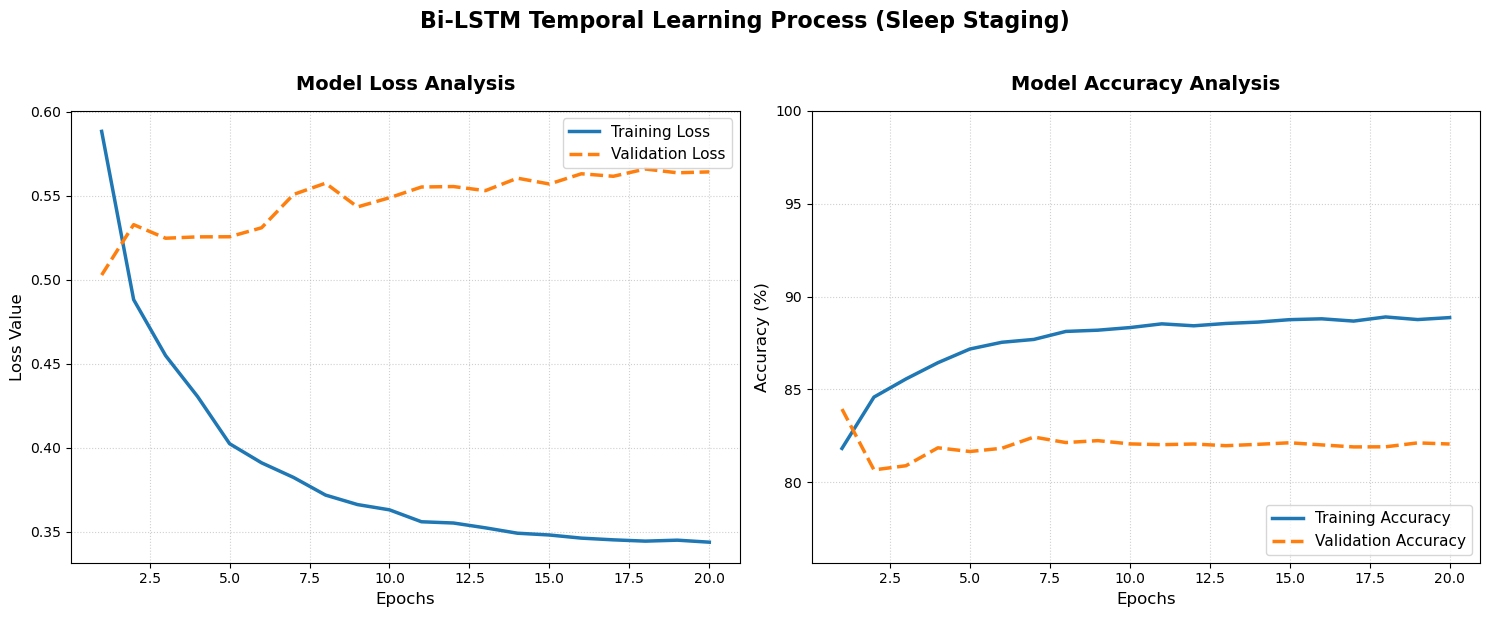

In [22]:
import matplotlib.pyplot as plt

epochs = range(1, len(TL) + 1)

# Convert accuracy to percentage
TA_pct = [a * 100 for a in TA]
VA_pct = [a * 100 for a in VA]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=100)

# ---------------------------
# Plot 1: Loss
# ---------------------------
ax1.plot(epochs, TL, linewidth=2.5, label='Training Loss')
ax1.plot(epochs, VL, linewidth=2.5, linestyle='--', label='Validation Loss')
ax1.set_title('Model Loss Analysis', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss Value', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)

# ---------------------------
# Plot 2: Accuracy
# ---------------------------
ax2.plot(epochs, TA_pct, linewidth=2.5, label='Training Accuracy')
ax2.plot(epochs, VA_pct, linewidth=2.5, linestyle='--', label='Validation Accuracy')
ax2.set_title('Model Accuracy Analysis', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)

# Safe y-limits
lower = max(0, min(VA_pct) - 5)
ax2.set_ylim(lower, 100)

ax2.legend(loc='lower right', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)

# ---------------------------
# Main Title
# ---------------------------
plt.suptitle(
    'Bi-LSTM Temporal Learning Process (Sleep Staging)',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

# SAVE FIRST
plt.savefig("figure1_training_validation.png", dpi=300, bbox_inches="tight")

# THEN SHOW
plt.show()

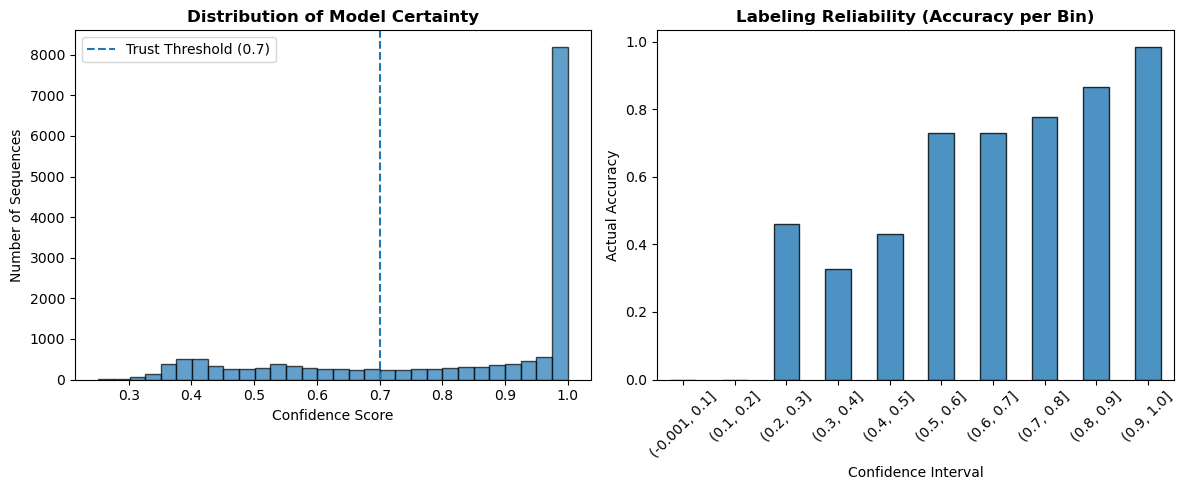


             AUTOMATIC SLEEP STAGE LABELING REPORT (VAL)
    Seq_Index True_Stage Auto_Predicted_Stage  Confidence_Score    Status
0           1        REM                  REM          0.998787  Reliable
1           2        REM                  REM          0.997910  Reliable
2           3        REM                  REM          0.998714  Reliable
3           4        REM                  REM          0.998774  Reliable
4           5        REM                  REM          0.998753  Reliable
5           6        REM                  REM          0.998483  Reliable
6           7        REM                  REM          0.998865  Reliable
7           8        REM                  REM          0.998711  Reliable
8           9        REM                  REM          0.998211  Reliable
9          10        REM                  REM          0.997806  Reliable
10         11        REM                  REM          0.998610  Reliable
11         12        REM                  REM         

In [24]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# --------------------------
# 1) GET PROBABILITIES (VAL)
# --------------------------
model.eval()
all_probs = []
all_true = []

with torch.no_grad():
    for Xb, yb in val_loader:   # ✅ val_loader exists
        Xb = Xb.to(device)
        logits = model(Xb)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_true.append(yb.numpy())

probs_array = np.concatenate(all_probs, axis=0)      # (N, 5)
true_indices = np.concatenate(all_true, axis=0)      # (N,)

# --------------------------
# 2) PRED + CONFIDENCE
# --------------------------
pred_indices = np.argmax(probs_array, axis=1)
confidences = np.max(probs_array, axis=1)

# --------------------------
# 3) MAP TO CLINICAL STAGES
# --------------------------
inv_label_map = {0: "W", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}

df_labels = pd.DataFrame({
    "Seq_Index": np.arange(1, len(pred_indices) + 1),
    "True_Stage": [inv_label_map[int(i)] for i in true_indices],
    "Auto_Predicted_Stage": [inv_label_map[int(i)] for i in pred_indices],
    "Confidence_Score": confidences,
})

# Flagging rule
THRESH = 0.70
df_labels["Status"] = np.where(df_labels["Confidence_Score"] >= THRESH,
                               "Reliable",
                               "RE-CHECK REQUIRED")

# Correctness
df_labels["Is_Correct"] = df_labels["True_Stage"] == df_labels["Auto_Predicted_Stage"]

# --------------------------
# 4) VISUALIZATION
# --------------------------
plt.figure(figsize=(12, 5))

# Plot 1: Confidence distribution
plt.subplot(1, 2, 1)
plt.hist(df_labels["Confidence_Score"], bins=30, edgecolor="black", alpha=0.7)
plt.axvline(THRESH, linestyle="--", label=f"Trust Threshold ({THRESH})")
plt.title("Distribution of Model Certainty", fontweight="bold")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Sequences")
plt.legend()

# Plot 2: Accuracy per confidence bin (reliability / calibration style)
plt.subplot(1, 2, 2)
bins = np.arange(0, 1.01, 0.1)
df_labels["Conf_Bin"] = pd.cut(df_labels["Confidence_Score"], bins=bins, include_lowest=True)
bin_accuracy = df_labels.groupby("Conf_Bin", observed=False)["Is_Correct"].mean()

bin_accuracy.plot(kind="bar", edgecolor="black", alpha=0.8)
plt.title("Labeling Reliability (Accuracy per Bin)", fontweight="bold")
plt.xlabel("Confidence Interval")
plt.ylabel("Actual Accuracy")
plt.xticks(rotation=45)

plt.tight_layout()

# Save BEFORE show (optional)
plt.savefig("figure_confidence_analysis.png", dpi=300, bbox_inches="tight")

plt.show()

# --------------------------
# 5) PRINT + OPTIONAL SAVE
# --------------------------
print("\n" + "="*70)
print("             AUTOMATIC SLEEP STAGE LABELING REPORT (VAL)")
print("="*70)
print(df_labels[["Seq_Index", "True_Stage", "Auto_Predicted_Stage", "Confidence_Score", "Status"]].head(20))
print("="*70)

# Optional: save full table
# df_labels.to_csv("auto_labeling_results_val.csv", index=False)

## II. Dataset Description

Experiments were conducted using the **Sleep-EDF Expanded (Sleep-EDF)** database, a publicly available benchmark dataset widely used in automatic sleep staging research. The dataset contains full-night polysomnography (PSG) recordings collected from adult subjects under controlled laboratory conditions.

Each recording includes synchronized **electroencephalogram (EEG)**, **electrooculogram (EOG)**, and **electromyogram (EMG)** signals, along with expert-annotated hypnograms. Sleep stages are scored according to standard clinical guidelines at a fixed temporal resolution of **30 seconds per epoch**.

In this study, sleep staging is formulated as a **five-class classification problem**, consisting of the following stages:

- Wake (W)  
- Non-REM Stage 1 (N1)  
- Non-REM Stage 2 (N2)  
- Non-REM Stage 3 (N3)  
- Rapid Eye Movement (REM)

Raw physiological signals are represented at the epoch level using engineered statistical features extracted from EEG, EOG, and EMG channels, including measures such as mean, standard deviation, and root mean square (RMS). Each row in the dataset corresponds to a single 30-second epoch.

To prevent subject-level data leakage, recordings are partitioned into **training and validation sets based on recording identity**, ensuring that all epochs from a given subject appear in only one split. This evaluation protocol reflects a realistic deployment scenario in which the model is assessed exclusively on **previously unseen subjects**.

The dataset exhibits a pronounced **class imbalance**, with Wake (W) and N2 comprising the majority of epochs, while transitional stages such as N1 and REM occur substantially less frequently. This imbalance reflects natural sleep architecture and motivates the use of **class-weighted optimization** during model training.

---

## III. Methodology

The proposed framework reformulates sleep staging from a point-in-time classification task into a **temporal sequence modeling problem**. Instead of treating each 30-second epoch independently, physiological features are grouped into fixed-length temporal windows to capture sleep dynamics over time.

Given the clinical standard of 30-second epoch intervals, the sequence length is set to **T = 20**, providing the model with a **10-minute temporal context**. For a sequence of feature vectors:

$$
\{x_1, x_2, \dots, x_T\}
$$

the model is trained to predict the sleep stage label corresponding to the **most recent epoch**.

### Feature Normalization

To ensure numerical stability and consistent optimization behavior, all input features undergo **Z-score normalization**:

$$
z = \frac{x - \mu}{\sigma}
$$

where the mean and standard deviation are computed exclusively from the training partition and applied to validation recordings to prevent data leakage.

### Model Architecture and Optimization

The core architecture consists of a two-layer Bi-Directional Long Short-Term Memory (Bi-LSTM) network. The Bi-LSTM processes sequences of consecutive 30-second epochs and produces a hidden representation at the final time step, which summarizes recent sleep dynamics. *Layer normalization* is applied to improve training stability, followed by a fully connected classifier that outputs logits over the five sleep stages.

Class probabilities are obtained via a Softmax operation, which is applied implicitly during training through the cross-entropy loss and explicitly during inference for confidence estimation.

To address class imbalance inherent in sleep data, the model is trained using a **class-weighted cross-entropy loss**, defined as:

$$
L = -\sum_{k=1}^{K} w_k \, y_k \log(\hat{y}_k)
$$

where the predicted probability corresponds to the model’s confidence for class *k*, the ground-truth label indicates the true sleep stage, and the class weight is computed from the training data to control the contribution of each sleep stage during optimization. Higher weights are assigned to underrepresented and transitional sleep stages (e.g., N1 and REM), ensuring they contribute more strongly to the learning objective.

Regularization is enforced through *dropout (rate = 0.3)*, and model parameters are optimized using *AdamW* with a weight decay of *1e-4*.

---

## IV. Results and Discussion

### Training Dynamics

Figure 1 illustrates the training and validation behavior of the proposed Bi-LSTM model.

<img src="figure1_training_validation.png" width="550">

**Figure 1:** *Training and validation loss and accuracy across epochs. Training loss decreases steadily while validation performance stabilizes, reflecting generalization to unseen subjects and the impact of class-weighted optimization.*

As illustrated in Figure 1, validation loss remains higher than training loss despite stable validation accuracy. This behavior reflects the impact of class imbalance in the sleep-stage distribution, where Wake (W) occurs substantially more frequently than other stages. To counter this imbalance, class-weighted optimization increases the penalty associated with misclassifications of less frequent and transitional stages such as N1 and REM. Consequently, even a small number of errors in these minority stages can lead to a relatively high validation loss, despite stable overall validation accuracy.

In addition, validation recordings consist of previously unseen subjects, introducing physiological variability in EEG, EOG, and EMG signal characteristics. This variability increases uncertainty near sleep-stage transitions, where errors are both more likely and more strongly penalized. As a result, validation loss remains elevated while accuracy continues to improve, reflecting increased sensitivity to minority sleep stages rather than reduced generalization.

### Quantitative Performance

Performance was evaluated on validation recordings consisting of unseen subjects. The sequence-based Bi-LSTM consistently outperforms the non-temporal XGBoost baseline:

| Model | Accuracy | Precision (Macro) | Recall (Macro) | F1 Score (Macro) |
|------|----------|-------------------|----------------|------------------|
| XGBoost (epoch-level) | 74.92% | 0.5590 | 0.6225 | 0.5745 |
| Bi-LSTM (sequence-level) | 83.94% | 0.6721 | 0.6325 | 0.6474 |

The Bi-LSTM achieves an **absolute accuracy improvement of 9.02 percentage points** over the epoch-level baseline. Improvements in Macro F1-score indicate enhanced recognition of minority and transitional sleep stages.

### Automatic Sleep Stage Labeling

Once trained, the proposed Bi-LSTM model performs fully automatic sleep stage labeling at the standard 30-second epoch resolution. During inference, the model receives sequences of physiological features derived from EEG, EOG, and EMG signals and predicts the sleep stage of the most recent epoch without requiring expert annotations. By sliding the temporal window forward across an entire recording, the system generates a complete automatically labeled hypnogram, directly comparable to expert-scored sleep annotations.

### Confidence-Aware Inference

In addition to predicted sleep stage labels, the Bi-LSTM model outputs an associated confidence score for each epoch, defined as the maximum predicted class probability. Higher confidence values are typically observed during stable sleep periods, whereas lower confidence values occur more frequently near sleep-stage transitions and physiologically ambiguous stages such as N1 and REM. This confidence measure provides an interpretable indication of prediction reliability and highlights epochs characterized by increased temporal uncertainty.

---

## References

1. Kemp, B., Zwinderman, A. H., Tuk, B., Kamphuisen, H. A. C., & Oberye, J. J. L. (2000). *Analysis of a sleep-dependent neuronal feedback loop: the slow-wave microcontinuity of the EEG*. IEEE Transactions on Biomedical Engineering, 47(9), 1185–1194.